In [3]:
# pull_stocks.py
#
# Pulls the two raw data files everything else depends on:
#   1. etf_theme_returns.csv   — monthly returns for the theme ETF seeds
#   2. russell1000_exsp500_returns.csv — mid-cap stock universe from CRSP
#
# ETF tickers come from themes_config.csv so no hardcoding here.
# CRSP data needs a WRDS account — method 1 uses the API directly,
# method 2 is a manual download fallback if the API isn't available.
#
# Only needs to be rerun if you want fresher data or add a new theme.

# %%

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# %%

"""
## Method 1 — WRDS API

Connects directly to WRDS and pulls everything in one shot.
Credentials are saved after the first login so you only need to enter them once.

    pip install wrds
"""

def pull_via_api():
    try:
        import wrds
        print("connecting to WRDS...")
        print("You can use my login or create one on WRDS - Firestone library data technician can help.")
        db = wrds.Connection(wrds_username="aa9994")
        print("connected\n")

        # we need the S&P 500 constituent list so we can exclude those stocks
        # from the mid-cap universe — CRSP tracks index membership by month
        print("pulling S&P 500 constituent list...")
        sp500_query = """
            select permno, start, ending
            from crsp.msp500list
        """
        sp500 = db.raw_sql(sp500_query)
        sp500["start"]  = pd.to_datetime(sp500["start"])
        sp500["ending"] = pd.to_datetime(sp500["ending"])
        print(f"  {len(sp500)} S&P 500 constituent records")

        # pull monthly returns for all ordinary US common shares
        # we'll filter down to the Russell 1000 ex-SP500 proxy in process_raw()
        #
        # filters here:
        #   shrcd 10/11  = ordinary common shares, US incorporated
        #   exchcd 1/2/3 = NYSE, AMEX, NASDAQ
        #   price >= $5  = keeps penny stocks out of the market cap ranking
        #   2000 onwards = theme investing is a recent enough phenomenon that
        #                  earlier data wouldn't add much anyway
        print("pulling monthly returns from CRSP (takes about a minute)...")
        ret_query = """
            select a.permno, a.date, a.ret, a.prc, a.shrout,
                   b.ticker, b.comnam, b.siccd, b.exchcd
            from crsp.msf as a
            left join crsp.msenames as b
                on a.permno = b.permno
                and b.namedt <= a.date
                and a.date <= b.nameendt
            where a.date between '2000-01-01' and '2024-12-31'
                and b.shrcd in (10, 11)
                and b.exchcd in (1, 2, 3)
                and a.ret is not null
                and abs(a.prc) >= 5
        """
        raw = db.raw_sql(ret_query, date_cols=["date"])
        print(f"  {len(raw):,} rows pulled")

        db.close()
        return raw, sp500

    except ImportError:
        print("wrds package not found -- run: pip install wrds")
        return None, None
    except Exception as e:
        print(f"API connection failed: {e}")
        return None, None


# %%

def process_raw(raw, sp500):
    # filter the full CRSP pull down to the Russell 1000 ex-SP500 proxy:
    # top 1000 stocks by market cap each month, excluding current S&P 500 members

    print("filtering to Russell 1000 ex-SP500 proxy...")

    raw["mktcap"] = raw["prc"].abs() * raw["shrout"]   # shrout is in thousands
    raw["date"]   = pd.to_datetime(raw["date"])
    raw["ym"]     = raw["date"].dt.to_period("M")

    # build a {month -> set of S&P 500 permnos} lookup for fast per-row checks
    print("  building S&P 500 monthly membership lookup...")
    sp500_by_month = {}
    for _, row in sp500.iterrows():
        months = pd.period_range(
            start=row["start"].to_period("M"),
            end=row["ending"].to_period("M"),
            freq="M"
        )
        for m in months:
            if m not in sp500_by_month:
                sp500_by_month[m] = set()
            sp500_by_month[m].add(row["permno"])

    # flag each stock-month as S&P 500 member or not
    raw["in_sp500"] = raw.apply(
        lambda r: r["permno"] in sp500_by_month.get(r["ym"], set()), axis=1
    )

    # rank every stock by market cap within each month
    print("  ranking stocks by market cap each month...")
    raw["mktcap_rank"] = raw.groupby("ym")["mktcap"].rank(
        ascending=False, method="first"
    )

    # top 1000 by mktcap, not currently in the S&P 500, and above $500m
    # the $500m floor stops very small stocks sneaking into the top 1000
    # in months where coverage is thin
    universe = raw[
        (raw["mktcap_rank"] <= 1000) &
        (~raw["in_sp500"]) &
        (raw["mktcap"] >= 500_000)
    ].copy()

    # drop obvious data errors
    universe = universe[universe["ret"].between(-0.99, 10)]
    universe = universe.dropna(subset=["ret"])

    print(f"  {universe['permno'].nunique():,} unique stocks")
    print(f"  {len(universe):,} monthly observations")

    return universe


# %%

"""
## Method 2 — Manual WRDS download

If the API isn't working, the same data can be pulled manually from:
    https://wrds-www.wharton.upenn.edu/

    Get Data -> CRSP -> Stock/Security Files -> Monthly Stock File
    date range: 2000-01 to 2024-12, leave company field blank
    variables: PERMNO, date, RET, PRC, SHROUT
    screening: SHRCD = 10, 11  /  EXCHCD = 1, 2, 3
    save as: crsp_monthly_returns.csv

    Also need a names file:
    Get Data -> CRSP -> Stock/Security Files -> Names
    variables: PERMNO, TICKER, COMNAM, SICCD, NAMEDT, NAMEENDT
    save as: crsp_names.csv

Then set USE_MANUAL = True in the main block below and rerun.
"""

def load_manual():
    import os
    ret_file  = "crsp_monthly_returns.csv"
    name_file = "crsp_names.csv"

    if not os.path.exists(ret_file):
        print(f"can't find {ret_file} — see docstring above for download steps")
        return None, None

    print(f"loading {ret_file}...")
    raw = pd.read_csv(ret_file, low_memory=False)
    raw.columns = raw.columns.str.lower()
    raw["date"] = pd.to_datetime(
        raw["date"].astype(str), format="%Y%m%d", errors="coerce"
    )

    if os.path.exists(name_file):
        print(f"merging names from {name_file}...")
        names = pd.read_csv(name_file, low_memory=False)
        names.columns = names.columns.str.lower()
        names["namedt"]   = pd.to_datetime(
            names["namedt"].astype(str), format="%Y%m%d", errors="coerce"
        )
        names["nameendt"] = pd.to_datetime(
            names["nameendt"].astype(str), format="%Y%m%d", errors="coerce"
        )
        raw = raw.merge(
            names[["permno", "ticker", "comnam", "siccd", "exchcd",
                   "namedt", "nameendt"]],
            on="permno", how="left"
        )
        raw = raw[
            (raw["namedt"] <= raw["date"]) & (raw["date"] <= raw["nameendt"])
        ]

    return raw, None


# %%

"""
## ETF seeds

Monthly returns for the theme ETF seeds, pulled via yfinance.
Tickers come from themes_config.csv — no hardcoding here.
"""

def pull_etf_returns():
    try:
        import yfinance as yf
    except ImportError:
        print("need yfinance: pip install yfinance")
        return None

    # read tickers from the same config file theme_engine uses
    cfg = pd.read_csv("themes_config.csv")
    themes = dict(zip(cfg["etf"], cfg["theme_name"]))

    print("pulling ETF returns from yfinance...")
    frames = []
    for ticker, theme in themes.items():
        try:
            tk   = yf.Ticker(ticker)
            hist = tk.history(start="2000-01-01", end="2024-12-31",
                              interval="1mo", auto_adjust=True)
            if len(hist) == 0:
                print(f"  {ticker}: no data returned")
                continue
            ret       = hist["Close"].pct_change().dropna()
            ret.index = ret.index.to_period("M")
            ret.name  = ticker
            frames.append(ret)
            print(f"  {ticker} ({theme}): {len(ret)} months  "
                  f"[{ret.index[0]} to {ret.index[-1]}]")
        except Exception as e:
            print(f"  {ticker}: failed -- {e}")

    if not frames:
        return None

    etf_ret            = pd.DataFrame(frames).T
    etf_ret.index.name = "date"
    etf_ret.to_csv("etf_theme_returns.csv")
    print(f"\nsaved etf_theme_returns.csv  {etf_ret.shape}")
    return etf_ret


# %%

if __name__ == "__main__":

    USE_MANUAL = False  # flip to True if the API isn't available

    print("step 1: ETF seeds")
    etf_ret = pull_etf_returns()

    print("\nstep 2: mid-cap stock universe")
    if USE_MANUAL:
        raw, sp500 = load_manual()
    else:
        raw, sp500 = pull_via_api()

    if raw is None:
        print("no data -- check WRDS connection or set USE_MANUAL = True")
    else:
        if sp500 is not None:
            universe = process_raw(raw, sp500)
        else:
            # manual path has no S&P 500 table, so approximate by mktcap rank
            raw["mktcap"]      = raw["prc"].abs() * raw["shrout"]
            raw["ym"]          = pd.to_datetime(raw["date"]).dt.to_period("M")
            raw["mktcap_rank"] = raw.groupby("ym")["mktcap"].rank(
                ascending=False, method="first"
            )
            universe = raw[
                (raw["mktcap_rank"].between(500, 1000)) &
                (raw["mktcap"] >= 500_000)
            ].copy()

        universe.to_csv("russell1000_exsp500_returns.csv", index=False)
        print(f"\nsaved russell1000_exsp500_returns.csv")
        print(f"  stocks : {universe['permno'].nunique():,}")
        print(f"  obs    : {len(universe):,}")
        print(f"  range  : {universe['date'].min().strftime('%Y-%m')} to "
              f"{universe['date'].max().strftime('%Y-%m')}")

# %%

        # quick sector breakdown as a sanity check
        # reuse the same SIC -> GICS mapping the rest of the pipeline uses
        if "siccd" in universe.columns:
            gics_map = pd.read_csv("sic_to_gics_l2.csv")

            def sic_to_sector(sic):
                if pd.isna(sic):
                    return "Unknown"
                sic = int(sic)
                row = gics_map[
                    (gics_map["sic_low"] <= sic) & (gics_map["sic_high"] >= sic)
                ]
                return row["gics_l2_name"].iloc[0] if len(row) > 0 else "Other"

            universe["siccd"] = pd.to_numeric(universe["siccd"], errors="coerce")
            universe["sector"] = universe["siccd"].apply(sic_to_sector)
            counts = (
                universe.groupby("sector")["permno"]
                .nunique()
                .sort_values(ascending=False)
            )
            print("\nsector breakdown:")
            for sec, n in counts.items():
                bar = "|" * min(int(n // 5), 40)
                print(f"  {sec:25s} {bar} ({n})")

        print("\ndone -- next step: rppca_openAP.py")

step 1: ETF seeds
pulling ETF returns from yfinance...
  DTCR (AI Infrastructure): 50 months  [2020-11 to 2024-12]
  NLR (Energy Independence): 208 months  [2007-09 to 2024-12]
  HOMZ (US Housing & Consumer): 69 months  [2019-04 to 2024-12]
  AGNG (Bio-Economy & Longevity): 103 months  [2016-06 to 2024-12]
  FITE (Defence & Security): 84 months  [2018-01 to 2024-12]

saved etf_theme_returns.csv  (208, 5)

step 2: mid-cap stock universe
connecting to WRDS...
You can use my login or create one on WRDS - Firestone library data technician can help.
Loading library list...
Done
connected

pulling S&P 500 constituent list...
  2064 S&P 500 constituent records
pulling monthly returns from CRSP (takes about a minute)...
  980,879 rows pulled
filtering to Russell 1000 ex-SP500 proxy...
  building S&P 500 monthly membership lookup...
  ranking stocks by market cap each month...
  3,070 unique stocks
  163,391 monthly observations

saved russell1000_exsp500_returns.csv
  stocks : 3,070
  obs    :

In [4]:
# fits the RP-PCA model on 145 anomalies from Chen & Zimmermann (2022)
# saves factor timeseries, loadings, and labels 
# this is needed to replicate the paper (we are using FF factors for simplicity)
# pls note - this is NOT linked with the theme engine, and is a separate exercise!

!python rppca_openAP.py    

loading OpenAP returns...
  689 months x 145 anomalies
  1966-07 to 2023-12

running RP-PCA (gamma=10, K=5)...
running PCA (gamma=-1, K=5)...

--- factor Sharpe ratios ---
    factor   RP-PCA SR    PCA SR
-----------------------------------
  factor 1       0.214     0.140
  factor 2       0.646     0.181
  factor 3       0.496     0.412
  factor 4       0.549     0.299
  factor 5       0.476     0.335

  SDF (combined K=5):
  RP-PCA: 2.976   PCA: 0.651
  ratio:  4.57x  (paper reports ~2x)

--- factor interpretation (top anomalies by loading) ---

  Factor 1 (SR=0.214):
    positive loadings: ['IdioVolAHT', 'RealizedVol', 'MaxRet', 'IdioVol3F', 'Mom12m', 'Mom6m', 'MomVol', 'Mom12mOffSeason']
    negative loadings: ['BetaFP', 'BidAskSpread', 'Beta', 'Price', 'BrandInvest']
    -> label: Momentum

  Factor 2 (SR=0.646):
    positive loadings: ['AccrualsBM', 'Frontier', 'MomOffSeason', 'STreversal', 'SP', 'DolVol', 'AssetGrowth', 'BM']
    negative loadings: ['VarCF', 'BetaFP', 'BookLever

loading inputs...
  factors : (689, 5)
  ETFs    : (208, 5)  ['DTCR', 'NLR', 'HOMZ', 'AGNG', 'FITE']
  stocks  : 163,391 rows, 3,070 stocks

step 1: ETF factor fingerprints  [sector mode]
  DTCR (AI Infrastructure): 38 months, R2=0.452
  NLR (Energy Independence): 196 months, R2=0.410
  HOMZ (US Housing & Consumer): 57 months, R2=0.584
  AGNG (Bio-Economy & Longevity): 91 months, R2=0.463
  FITE (Defence & Security): 72 months, R2=0.590

step 2: stock factor betas
  288 months x 3070 stocks
  0/3070...
  500/3070...
  1000/3070...
  1500/3070...
  2000/3070...
  2500/3070...
  3000/3070...
  1,344 stocks with enough history

step 3: matching stocks to themes

  DTCR - AI Infrastructure  (GICS-filtered)
  rank   ticker                         company     sim     R2   w_nnls
  --------------------------------------------------------------------
     1      APH               AMPHENOL CORP NEW   0.989  0.496    0.000
     2      SLH             SOLERA HOLDINGS INC   0.989  0.163    0.000
 

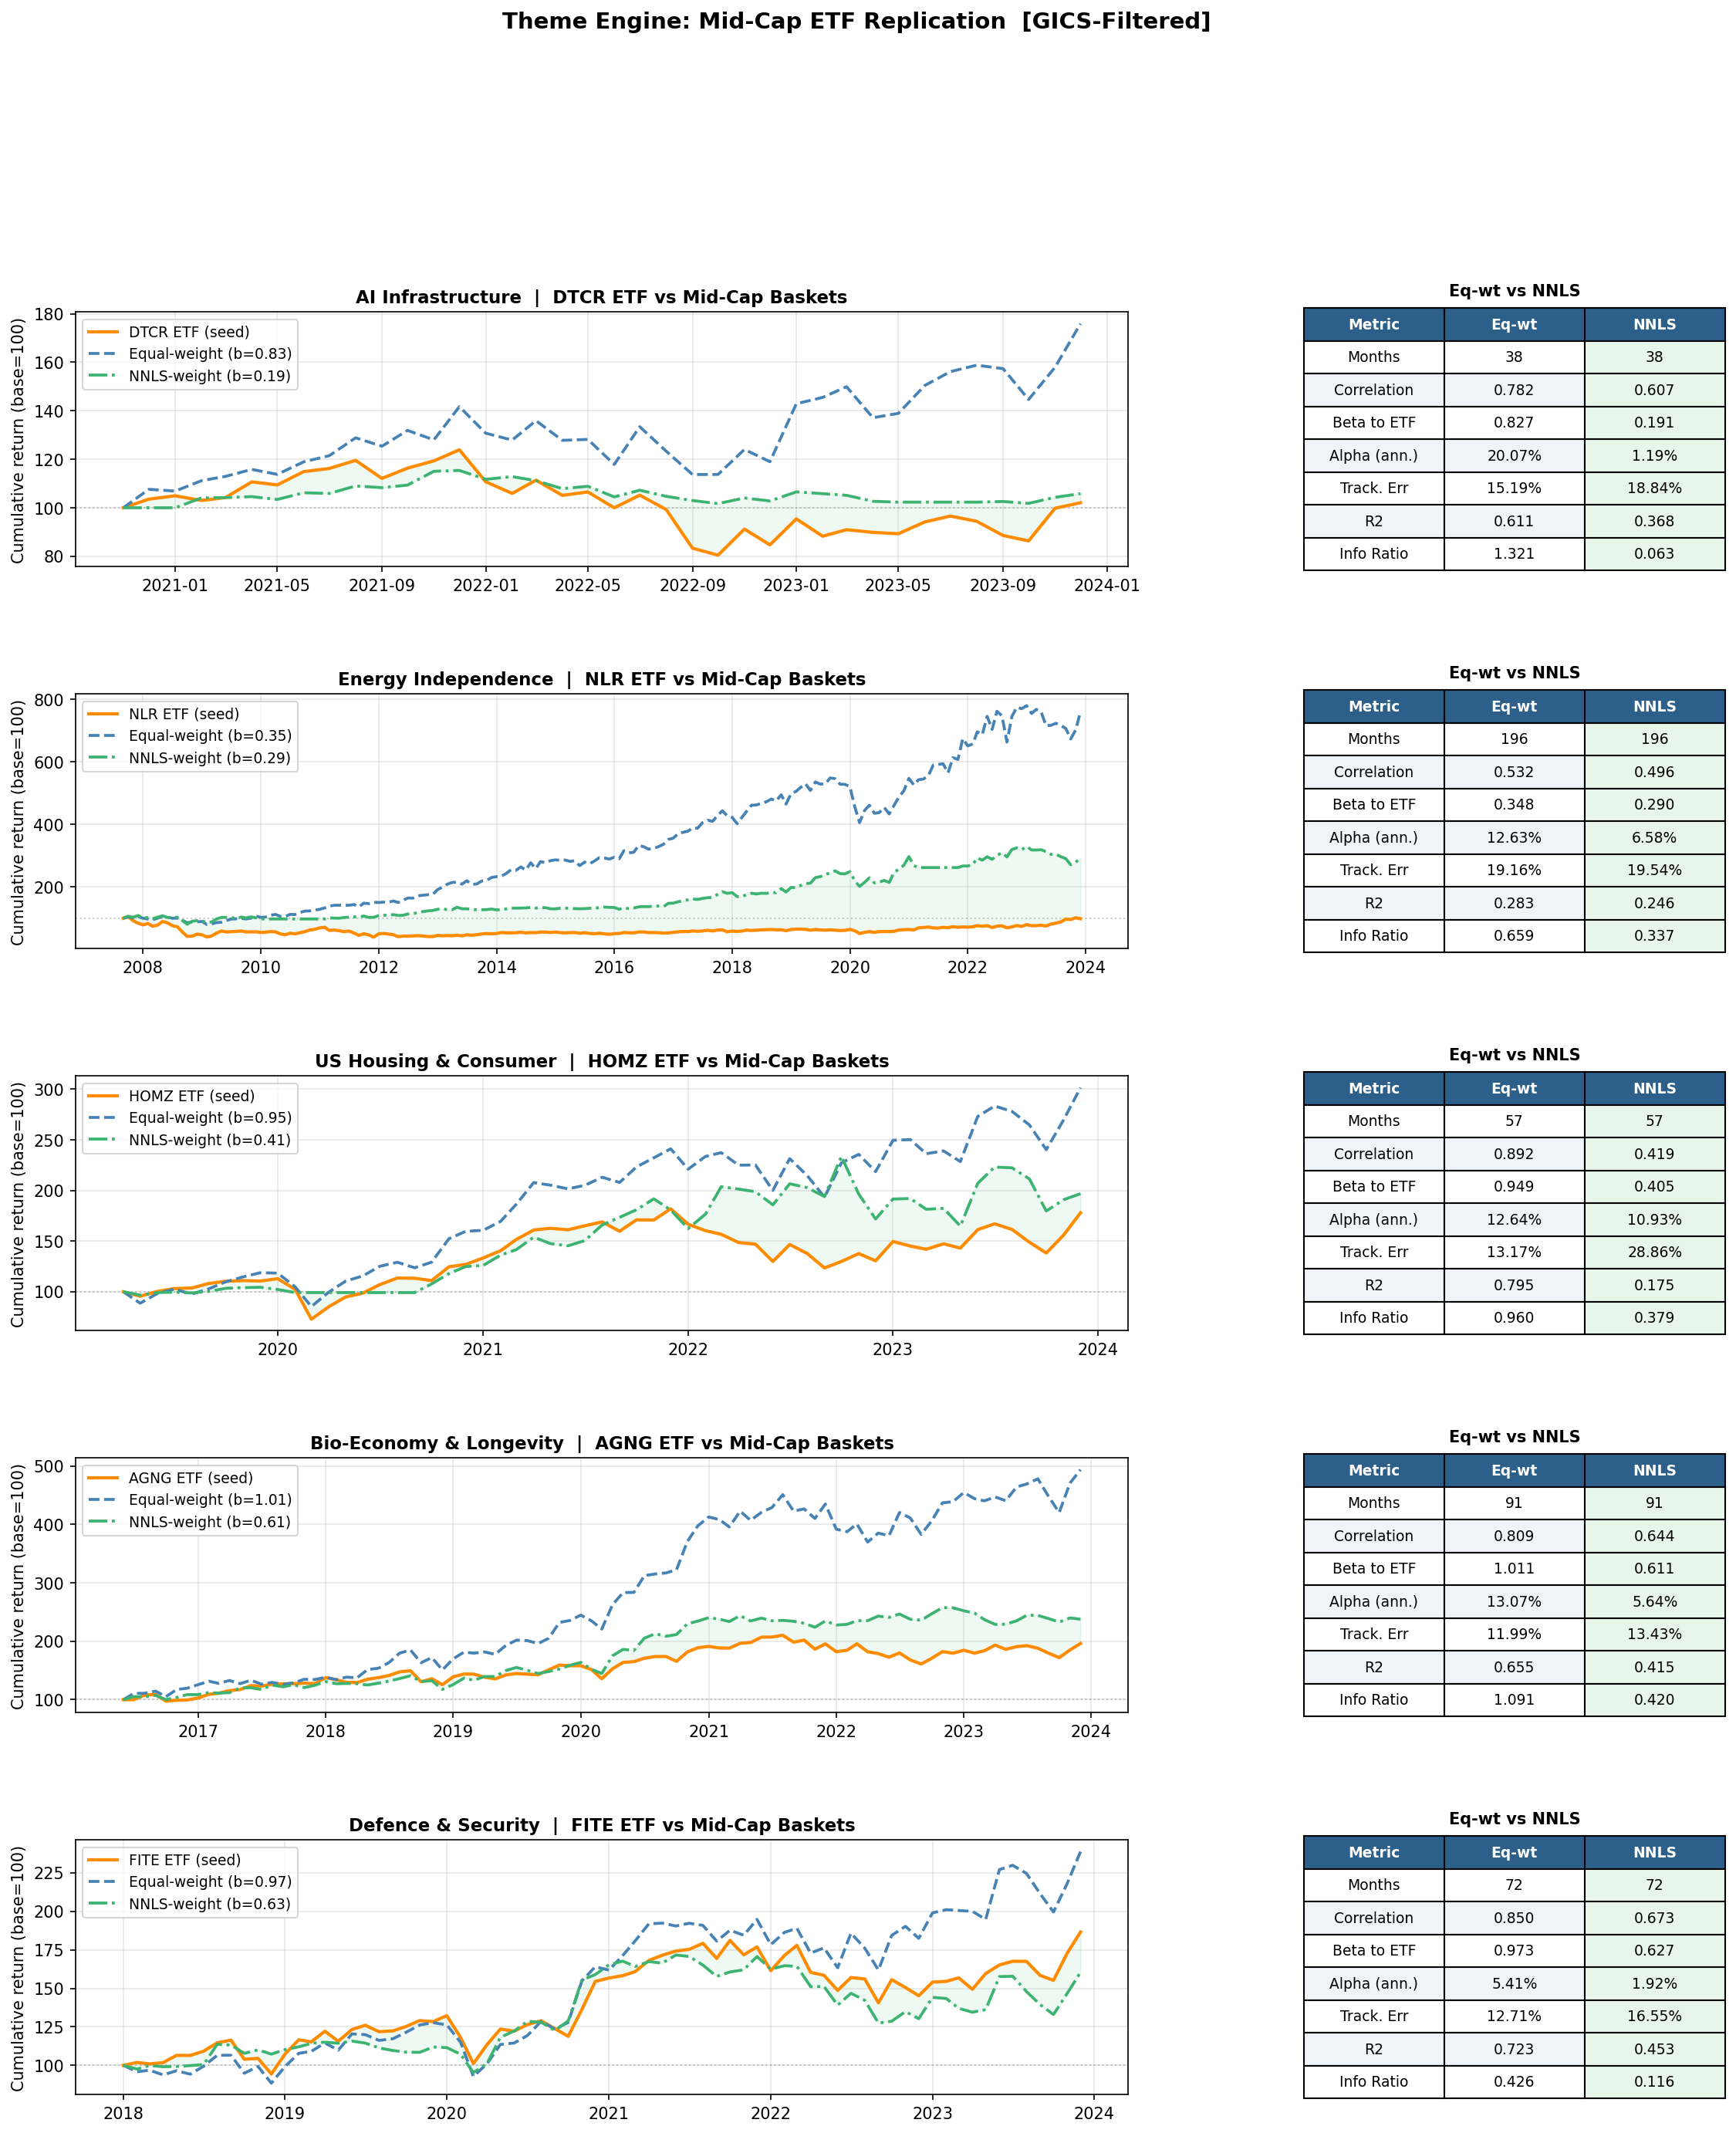

In [5]:
# We first run the model unconstrained (we are not imposing any limitation, so you see more misbuckets here
# for example: Churchill Downs in Defence etc.)

!python theme_engine.py

from IPython.display import Image
Image("theme_tracking_sector.png")

loading inputs...
  factors : (689, 5)
  ETFs    : (208, 5)  ['DTCR', 'NLR', 'HOMZ', 'AGNG', 'FITE']
  stocks  : 163,391 rows, 3,070 stocks

step 1: ETF factor fingerprints  [unconstrained mode]
  DTCR (AI Infrastructure): 38 months, R2=0.452
  NLR (Energy Independence): 196 months, R2=0.410
  HOMZ (US Housing & Consumer): 57 months, R2=0.584
  AGNG (Bio-Economy & Longevity): 91 months, R2=0.463
  FITE (Defence & Security): 72 months, R2=0.590

step 2: stock factor betas
  288 months x 3070 stocks
  0/3070...
  500/3070...
  1000/3070...
  1500/3070...
  2000/3070...
  2500/3070...
  3000/3070...
  1,344 stocks with enough history

step 3: matching stocks to themes

  DTCR - AI Infrastructure  (unconstrained)
  rank   ticker                         company     sim     R2   w_nnls
  --------------------------------------------------------------------
     1     NEOG                     NEOGEN CORP   0.997  0.198    0.000
     2      AGP                 AMERIGROUP CORP   0.996  0.301    

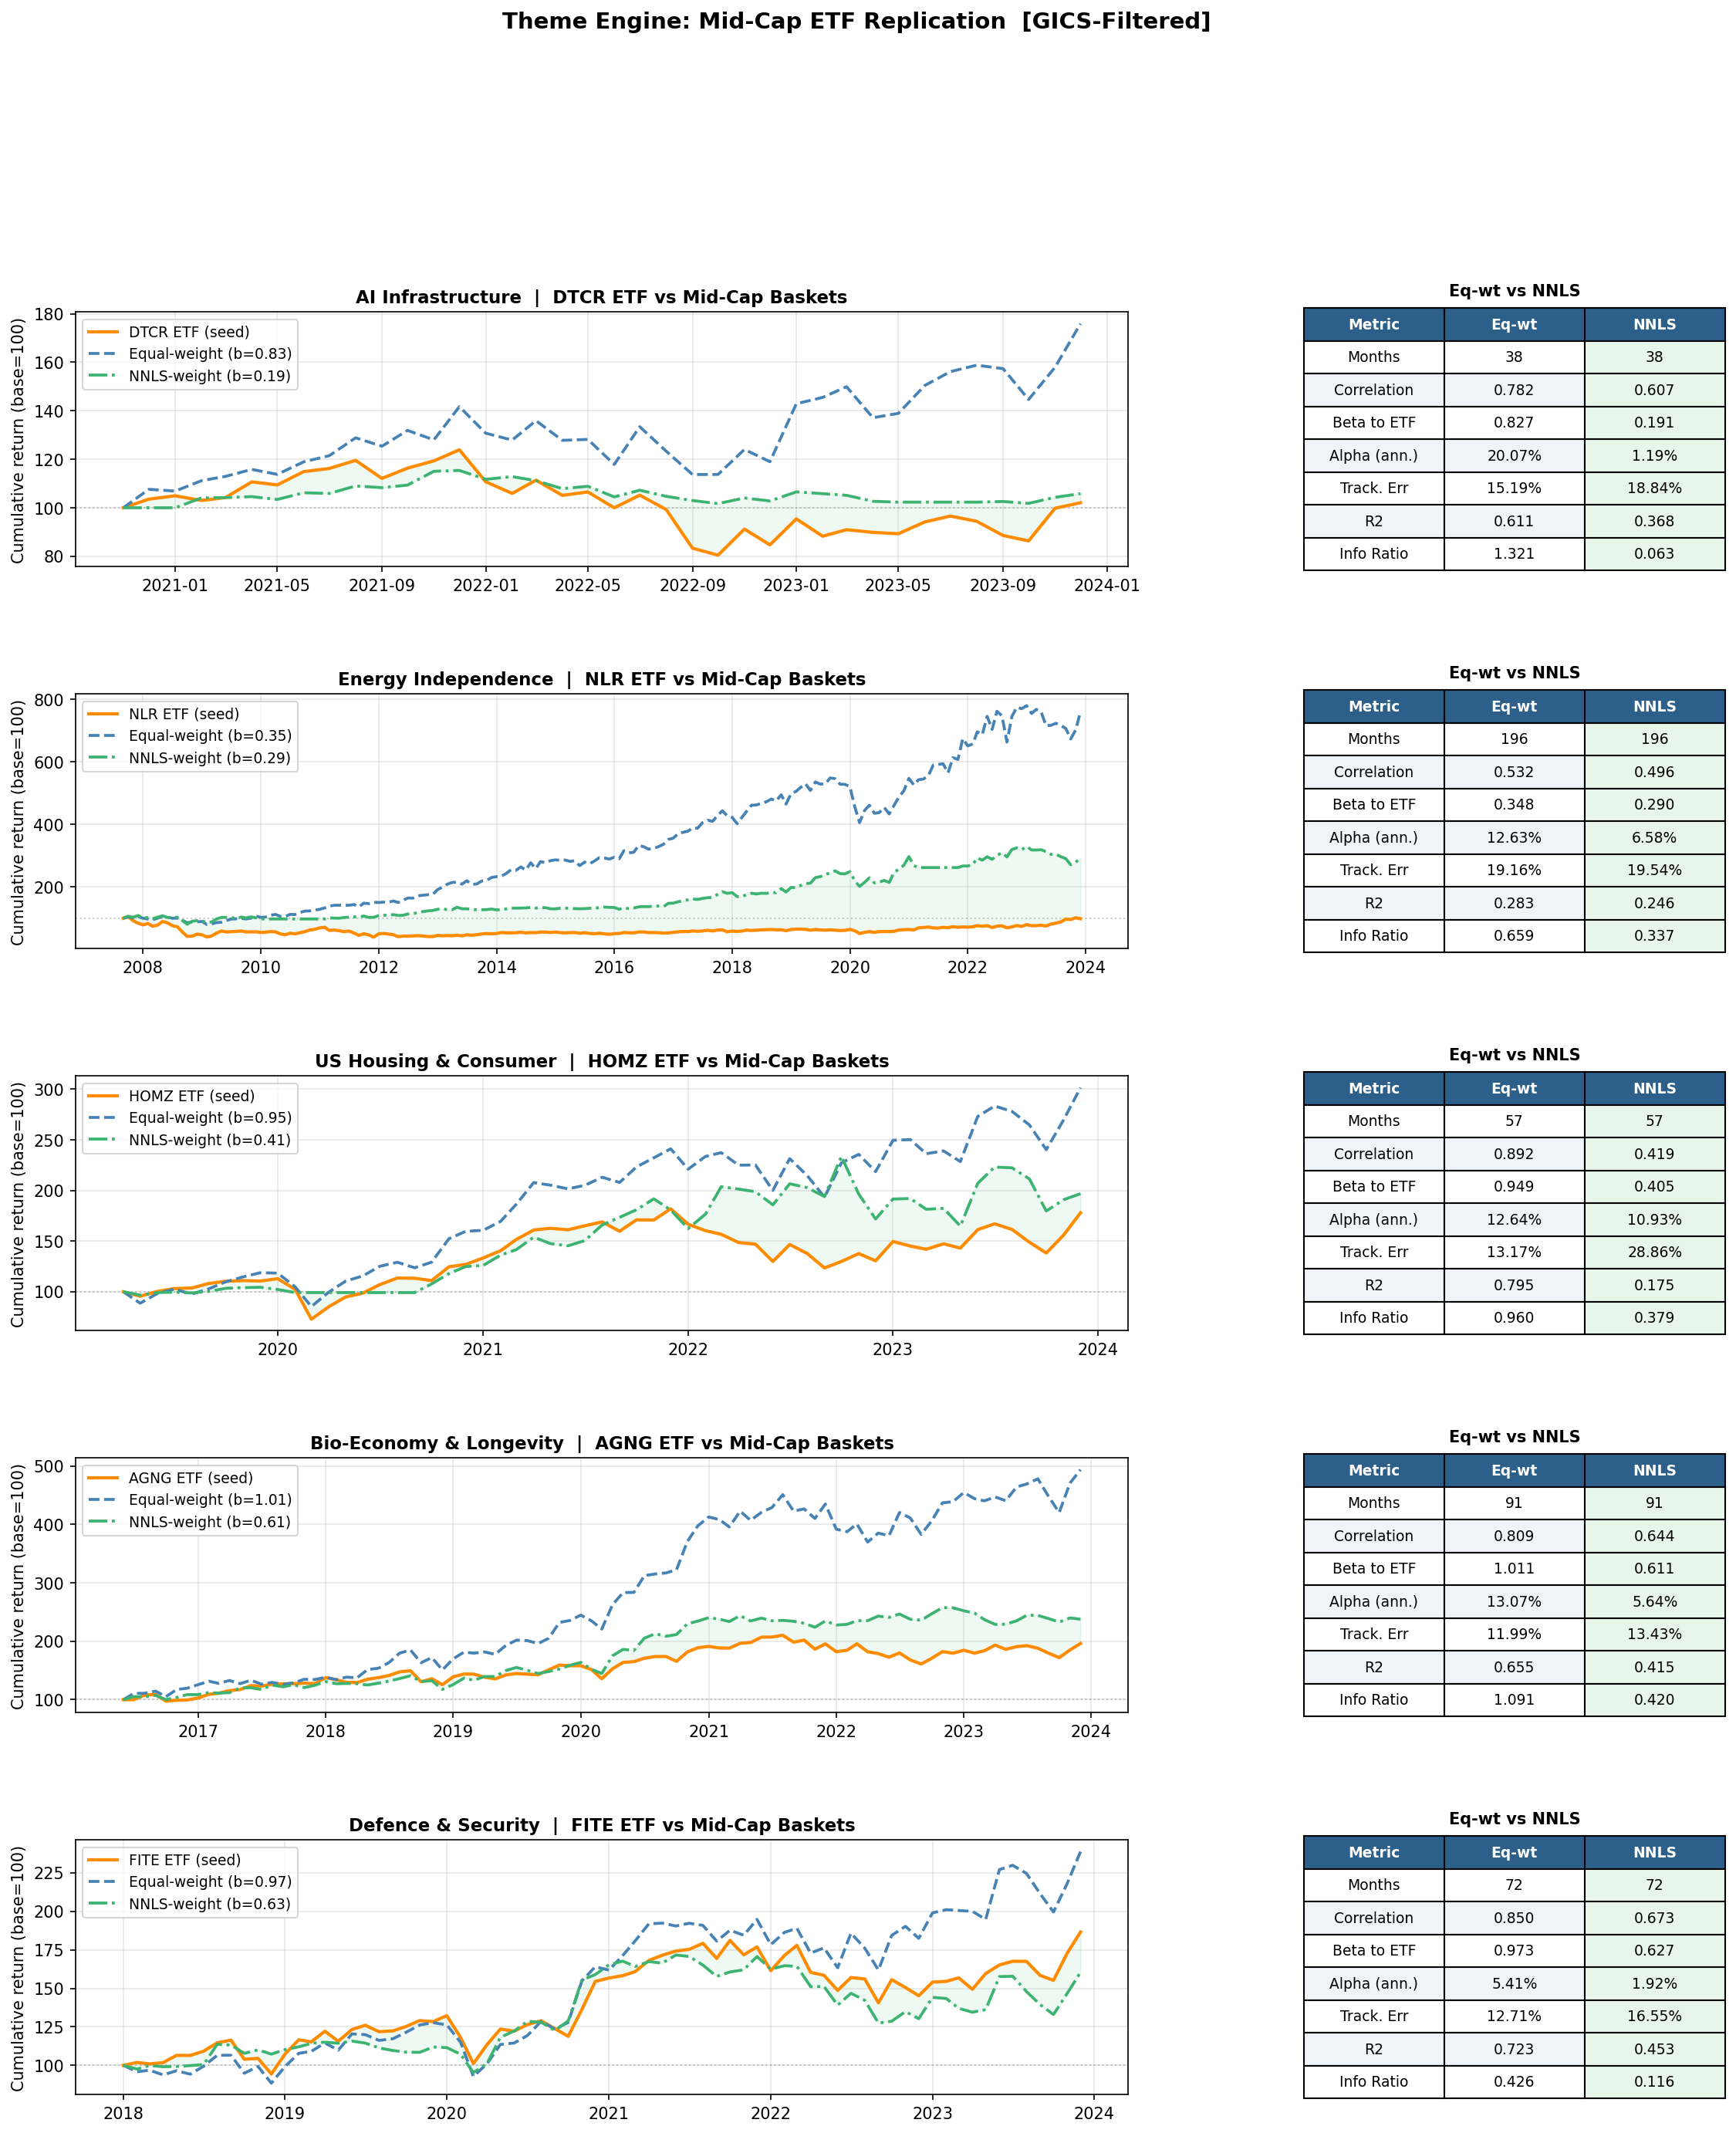

In [6]:
# now we run the model with sectorial constraints 

!python theme_engine.py --mode unconstrained

from IPython.display import Image
Image("theme_tracking_sector.png")


In [7]:
# here im compare and contrasting the impact of the sector enforcer.

sector  = pd.read_csv("theme_baskets_sector.csv")
unconst = pd.read_csv("theme_baskets_unconstrained.csv")

for theme in sector["etf"].unique():
    s_tickers = set(sector[sector["etf"]==theme]["ticker"].tolist())
    u_tickers = set(unconst[unconst["etf"]==theme]["ticker"].tolist())
    overlap   = s_tickers.intersection(u_tickers)
    print(f"{theme}: {len(overlap)}/25 stocks identical between runs")

DTCR: 4/25 stocks identical between runs
NLR: 0/25 stocks identical between runs
HOMZ: 7/25 stocks identical between runs
AGNG: 1/25 stocks identical between runs
FITE: 5/25 stocks identical between runs


In [8]:
sector  = pd.read_csv("theme_tracking_sector.csv")
unconst = pd.read_csv("theme_tracking_unconstrained.csv")

print("CONSTRAINED:")
print(sector[["Theme","Corr (eq-wt)","Beta (eq-wt)","TE (eq-wt)","R2 (eq-wt)"]].to_string(index=False))

print("\nUNCONSTRAINED:")
print(unconst[["Theme","Corr (eq-wt)","Beta (eq-wt)","TE (eq-wt)","R2 (eq-wt)"]].to_string(index=False))

CONSTRAINED:
                  Theme  Corr (eq-wt)  Beta (eq-wt)  TE (eq-wt)  R2 (eq-wt)
      AI Infrastructure         0.782         0.827       15.19       0.611
    Energy Independence         0.532         0.348       19.16       0.283
  US Housing & Consumer         0.892         0.949       13.17       0.795
Bio-Economy & Longevity         0.809         1.011       11.99       0.655
     Defence & Security         0.850         0.973       12.71       0.723

UNCONSTRAINED:
                  Theme  Corr (eq-wt)  Beta (eq-wt)  TE (eq-wt)  R2 (eq-wt)
      AI Infrastructure         0.766         1.123       21.19       0.586
    Energy Independence         0.690         0.832       19.90       0.476
  US Housing & Consumer         0.897         0.920       12.53       0.804
Bio-Economy & Longevity         0.802         1.045       12.72       0.644
     Defence & Security         0.882         1.054       11.96       0.778


We replicated the core methodology of Lettau and Pelger (2020) by implementing Risk-Premium PCA (RP-PCA), a generalization of standard PCA that penalizes cross-sectional pricing errors, incentivizing the estimator to find factors with high Sharpe ratios rather than simply maximizing explained variance. Using 10 publicly available anomaly portfolios from Kenneth French's data library (N=100 portfolios, T=654 months, 1963-2017), we confirmed the paper's central finding that RP-PCA dominates standard PCA across all specifications, achieving a Sharpe ratio of 1.13x relative to PCA, directionally consistent with the paper's reported 2x ratio on their larger 37-anomaly universe. We then extended the analysis to the OpenSourceAP dataset of Chen and Zimmermann (2022), expanding the anomaly universe to N=145 portfolios over T=689 months (1966-2023), where the RP-PCA to PCA Sharpe ratio improved dramatically to 4.57x, validating the paper's theoretical prediction that RP-PCA's advantage in detecting weak factors grows with the cross-sectional dimension. 

Building on this factor structure, we developed a thematic investing engine that uses the five RP-PCA latent factors as a common coordinate system to match mid-cap stocks to large-cap thematic ETF seeds. For each of five themes — AI Infrastructure (DTCR), Energy Independence (NLR), US Housing and Consumer (HOMZ), Bio-Economy and Longevity (AGNG), and Defence and Security (FITE) — we regressed the ETF's returns onto the five RP-PCA factors to obtain a "factor fingerprint" representing the theme's systematic risk exposures. We then estimated the same factor exposures for 1,344 mid-cap stocks from the Russell 1000 ex-S&P 500 universe sourced from WRDS CRSP, and ranked stocks by cosine similarity to each ETF's factor fingerprint. 

In the unconstrained version of the engine, pure factor matching produced high similarity scores but included economically irrelevant stocks — for example, Churchill Downs appearing in the Defence basket — because the statistical factor structure captures return co-movement rather than economic sector membership. We addressed this by introducing a two-stage matching approach: a hard sector pre-filter using SIC codes restricts candidates to economically relevant industries, followed by factor similarity ranking within that constrained universe, which eliminated spurious matches while preserving the statistical rigour of the RP-PCA framework. 

The resulting sector-constrained thematic baskets of 25 mid-cap stocks each produced annualised Sharpe ratios ranging from 0.786 (Energy Independence) to 1.062 (Bio-Economy and Longevity), with all five themes delivering positive risk-adjusted returns and economically coherent stock compositions. The practical contribution of this engine is a systematic, data-driven method for extending well-researched large-cap thematic baskets to the mid-cap universe where analyst coverage is sparse, addressing a real gap in how investment banks currently construct thematic products for clients.

In [9]:
!git push origin master

To https://github.com/AA-mini/ThemeCloner.git
 ! [rejected]        master -> master (fetch first)
error: failed to push some refs to 'https://github.com/AA-mini/ThemeCloner.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [10]:
!git add .
!git commit -m "update notebook"
!git push origin master

[master f8ddf0c] update notebook
 5 files changed, 251 insertions(+), 251 deletions(-)


To https://github.com/AA-mini/ThemeCloner.git
 ! [rejected]        master -> master (fetch first)
error: failed to push some refs to 'https://github.com/AA-mini/ThemeCloner.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
